# 02 — Feature Engineering & Prediction

This notebook contains the core analysis pipeline for the DJIA price prediction project.

## 1. Setup & Imports


In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load the scraped headlines dataset
df_mi = pd.read_csv("../data/correlationimp.csv")


## 2. Feature Engineering

This section transforms raw headlines into predictive features:
1. **Sentiment Scoring**: Uses VADER to generate a compound sentiment score [-1, 1] for each headline.
2. **Volume-Weighting**: Aggregates daily sentiment by weighting it against DJIA trading volume, ensuring days with higher market activity have proportionally weighted sentiment.
3. **Temporal Features**: Constructs Exponentially Weighted Moving Averages (EWMA) at 3, 7, 14, and 30-day scales to capture short- and medium-term sentiment trends.


In [3]:

import numpy as np

# Initialize the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# List of stock codes in the Dow Jones index
stock_codes = [
    "MMM", "AXP", "AMGN", "AAPL", "BA", "CAT", "CVX", "CSCO", "KO", 
    "DOW", "GS", "HD", "HON", "IBM", "INTC", "JNJ", "JPM", "MCD", 
    "MRK", "MSFT", "NKE", "PG", "CRM", "TRV", "UNH", "VZ", "V", 
    "WBA", "WMT", "DIS"
]

# Download daily trading volume for each stock using yfinance
all_volumes = []
for code in stock_codes:
    data = yf.download(code, start='2022-01-01', end='2023-12-31')[['Volume']].assign(code=code)
    data.reset_index(inplace=True)
    all_volumes.append(data)

# Combine all volumes into a single DataFrame
volume_df = pd.concat(all_volumes, ignore_index=True)
volume_df.rename(columns={'Date': 'date', 'Volume': 'trading_volume'}, inplace=True)
volume_df['date'] = pd.to_datetime(volume_df['date'])

# Confirm that volume_df has the required columns
print("Volume DataFrame Columns:", volume_df.columns)
print(volume_df.head())

# Function to calculate sentiment score
def get_sentiment_score(title):
    sentiment = analyzer.polarity_scores(title)
    return sentiment['compound']

# Apply sentiment analysis to each news title and store in a new column
df_mi['sentiment_score'] = df_mi['title'].apply(get_sentiment_score)
df_mi['date'] = pd.to_datetime(df_mi['date'])

# Merge trading volume with df_mi based on 'code' and 'date'
df_mi = pd.merge(df_mi, volume_df[['code', 'date', 'trading_volume']], on=['code', 'date'], how='left')
df_mi['trading_volume'] = df_mi['trading_volume'].fillna(0)  # Fill missing trading volume with 0

# Group by company and date to calculate the average sentiment score and sum of volume
company_daily_sentiment = df_mi.groupby(['code', 'date']).agg({
    'sentiment_score': 'mean',
    'trading_volume': 'sum'
}).reset_index()

# Calculate volume-weighted sentiment score for the Dow Jones index for each day
def calculate_volume_weighted_sentiment(df):
    return (df['sentiment_score'] * df['trading_volume']).sum() / df['trading_volume'].sum()

dow_jones_daily_sentiment = company_daily_sentiment.groupby('date').apply(calculate_volume_weighted_sentiment).reset_index()
dow_jones_daily_sentiment.columns = ['date', 'dow_jones_daily_sentiment']

# Fetch Dow Jones price data for 2022-2023 using yfinance
dow_jones_data = yf.download('^DJI', start='2022-01-01', end='2023-12-31')
dow_jones_data.reset_index(inplace=True)

# Merge the daily sentiment data with Dow Jones price data
combined_data = pd.merge(dow_jones_data[['Date', 'High', 'Low', 'Close', 'Volume', 'Open']], 
                         dow_jones_daily_sentiment, 
                         left_on='Date', right_on='date', how='left')
combined_data.drop(columns=['date'], inplace=True)
combined_data['dow_jones_daily_sentiment'].fillna(0, inplace=True)

# Additional Features
# Exponentially Weighted Moving Averages (EWMA) of sentiment scores
combined_data['sentiment_ewma_3'] = combined_data['dow_jones_daily_sentiment'].ewm(span=3, adjust=False).mean()
combined_data['sentiment_ewma_7'] = combined_data['dow_jones_daily_sentiment'].ewm(span=7, adjust=False).mean()
combined_data['sentiment_ewma_14'] = combined_data['dow_jones_daily_sentiment'].ewm(span=14, adjust=False).mean()
combined_data['sentiment_ewma_30'] = combined_data['dow_jones_daily_sentiment'].ewm(span=30, adjust=False).mean()

# Cumulative Sentiment Change (7-day vs 3-day)
combined_data['cumulative_sentiment_change'] = combined_data['sentiment_ewma_7'] - combined_data['sentiment_ewma_3']

# Sentiment Volatility
combined_data['sentiment_volatility'] = combined_data['dow_jones_daily_sentiment'].rolling(window=5).std()

# Lagged Sentiment Features (1-3 days)
combined_data['lagged_sentiment_1'] = combined_data['dow_jones_daily_sentiment'].shift(1)
combined_data['lagged_sentiment_2'] = combined_data['dow_jones_daily_sentiment'].shift(2)
combined_data['lagged_sentiment_3'] = combined_data['dow_jones_daily_sentiment'].shift(3)

# Volume-weighted sentiment feature
combined_data['sentiment_volume_weighted'] = combined_data['dow_jones_daily_sentiment'] * combined_data['Volume']

# Sentiment-to-Volatility Ratio
combined_data['sentiment_volatility_ratio'] = combined_data['sentiment_ewma_7'] / combined_data['sentiment_volatility']

# Fill any NaN values in the newly created columns
combined_data.fillna(0, inplace=True)

# Drop any rows with null values after feature creation
combined_data.dropna(inplace=True)

# Display the final combined dataset with new features
print("Combined Data with New Features Sample:")
print(combined_data.head(50))

# Export to CSV for further analysis
#combined_data.to_csv("final_gpt_enhanced.csv", index=False)


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%*******

Volume DataFrame Columns: Index(['date', 'trading_volume', 'code'], dtype='object')
        date  trading_volume code
0 2022-01-03         2309117  MMM
1 2022-01-04         3016551  MMM
2 2022-01-05         3531070  MMM
3 2022-01-06         2996458  MMM
4 2022-01-07         3349039  MMM


C:\Users\moraz\AppData\Local\Temp\ipykernel_28912\3297268885.py:54: RuntimeWarning: invalid value encountered in double_scalars
  return (df['sentiment_score'] * df['trading_volume']).sum() / df['trading_volume'].sum()
[*********************100%%**********************]  1 of 1 completed

Combined Data with New Features Sample:
         Date          High           Low         Close     Volume  \
0  2022-01-03  36595.820312  36246.449219  36585.058594  347930000   
1  2022-01-04  36934.839844  36636.000000  36799.648438  435080000   
2  2022-01-05  36952.648438  36400.390625  36407.109375  462040000   
3  2022-01-06  36464.191406  36200.679688  36236.468750  385890000   
4  2022-01-07  36382.839844  36111.531250  36231.660156  356110000   
5  2022-01-10  36175.210938  35639.910156  36068.871094  430680000   
6  2022-01-11  36271.468750  35769.378906  36252.019531  356850000   
7  2022-01-12  36453.488281  36168.148438  36290.320312  310180000   
8  2022-01-13  36513.878906  36044.218750  36113.621094  343640000   
9  2022-01-14  35996.429688  35641.488281  35911.808594  389200000   
10 2022-01-18  35661.761719  35262.019531  35368.468750  427260000   
11 2022-01-19  35547.828125  35015.488281  35028.648438  393080000   
12 2022-01-20  35490.199219  34670.121094  34715.3

## 3. Feature Selection



In [5]:
combined_data = combined_data[['Close', 'Low', 'High', 'Open', 'sentiment_ewma_30', 
    'sentiment_ewma_14', 'sentiment_ewma_7', 'sentiment_volatility_ratio']]
    
combined_data
combined_data.to_csv("eda.csv")


## 4. Exploratory Data Analysis (EDA)



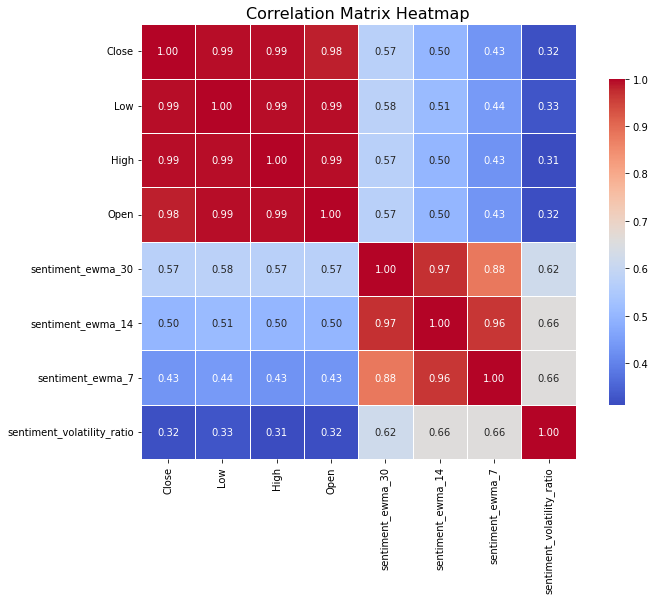

Correlation of all columns with 'Close':
Close                         1.000000
Low                           0.993031
High                          0.991987
Open                          0.983082
sentiment_ewma_30             0.572247
sentiment_ewma_14             0.499792
sentiment_ewma_7              0.431522
sentiment_volatility_ratio    0.317964
Name: Close, dtype: float64


In [18]:
# Load the dataset
file_path = combined_data  # Replace this with the actual path or data
data = file_path

# Drop non-numeric columns, if any
numeric_data = data.select_dtypes(include=[float, int])

# Calculate correlation matrix
correlation_matrix = numeric_data.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Create a heatmap with annotations
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True, cbar_kws={'shrink': 0.75})

# Set title for better readability
plt.title('Correlation Matrix Heatmap', fontsize=16)

# Show the plot
plt.show()

# Optional: If you are interested in the correlation of 'Close' specifically
close_corr = correlation_matrix['Close'].sort_values(ascending=False)
print("Correlation of all columns with 'Close':")
print(close_corr)


## 5. LSTM Baseline (No Sentiment Features)

We first establish a baseline model predicting the DJIA `Close` price using *only* traditional market features (Open, High, Low, Close).
- **Architecture**: LSTM (128 units) -> Dropout (0.3) -> Dense (1)


Epoch 1/50
21/22 [===========================>..] - ETA: 0s - loss: 0.0589
Epoch 1: val_loss improved from inf to 0.03442, saving model to best_model.h5
22/22 [==============================] - 5s 77ms/step - loss: 0.0586 - val_loss: 0.0344
Epoch 2/50
21/22 [===========================>..] - ETA: 0s - loss: 0.0109
Epoch 2: val_loss improved from 0.03442 to 0.03271, saving model to best_model.h5
22/22 [==============================] - 1s 42ms/step - loss: 0.0108 - val_loss: 0.0327
Epoch 3/50
21/22 [===========================>..] - ETA: 0s - loss: 0.0100
Epoch 3: val_loss improved from 0.03271 to 0.01687, saving model to best_model.h5
22/22 [==============================] - 1s 41ms/step - loss: 0.0100 - val_loss: 0.0169
Epoch 4/50
21/22 [===========================>..] - ETA: 0s - loss: 0.0087
Epoch 4: val_loss improved from 0.01687 to 0.01141, saving model to best_model.h5
22/22 [==============================] - 1s 41ms/step - loss: 0.0087 - val_loss: 0.0114
Epoch 5/50
21/22 [======

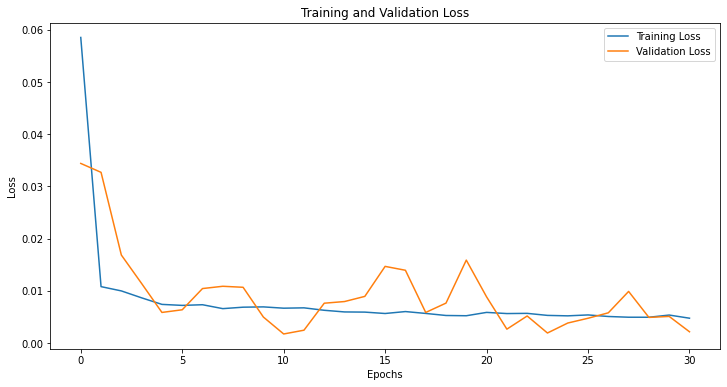

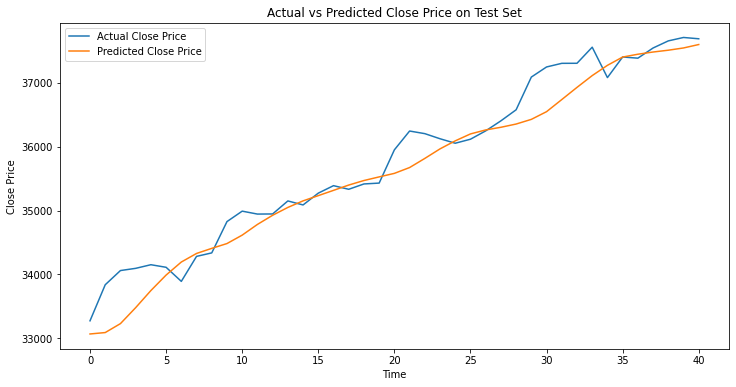

In [7]:

# Load and select the best features based on correlation with 'Close'
data = combined_data

# Selecting the best features based on correlation
selected_features = [
    'Close', 'Low', 'High', 'Open'
]
data = data[selected_features]

# Split data into training and testing sets
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

# Prepare the data for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 1:])  # Exclude 'Close' from X
        Y.append(dataset[i + look_back, 0])       # Use 'Close' as Y
    return np.array(X), np.array(Y)

look_back = 60  # Using 60 previous timesteps to predict the next timestep
X_train, y_train = create_dataset(train_scaled, look_back)
X_test, y_test = create_dataset(test_scaled, look_back)

# Reshape input to be [samples, time steps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Build LSTM model with specified hyperparameters
model = Sequential()
model.add(LSTM(128, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))  # Dropout rate set to 0.3
model.add(Dense(1))

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

# Model checkpointing and early stopping callbacks
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train the model with early stopping and model checkpointing
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=16,  # Batch size set to 16
    validation_data=(X_test, y_test), 
    callbacks=[checkpoint, early_stopping], 
    verbose=1
)

# Load the best model
model.load_weights('best_model.h5')

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions and actual values to compute metrics
train_predict = scaler.inverse_transform(np.concatenate((train_predict, np.zeros((train_predict.shape[0], data.shape[1] - 1))), axis=1))[:, 0]
y_train = scaler.inverse_transform(np.concatenate((y_train.reshape(-1, 1), np.zeros((y_train.shape[0], data.shape[1] - 1))), axis=1))[:, 0]

test_predict = scaler.inverse_transform(np.concatenate((test_predict, np.zeros((test_predict.shape[0], data.shape[1] - 1))), axis=1))[:, 0]
y_test = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], data.shape[1] - 1))), axis=1))[:, 0]

# --- Evaluation Metrics ---

# 1. RMSE
train_rmse = sqrt(mean_squared_error(y_train, train_predict))
test_rmse = sqrt(mean_squared_error(y_test, test_predict))
print(f'Train RMSE: {train_rmse:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')

# 2. MAE
train_mae = mean_absolute_error(y_train, train_predict)
test_mae = mean_absolute_error(y_test, test_predict)
print(f'Train MAE: {train_mae:.2f}')
print(f'Test MAE: {test_mae:.2f}')

# 3. R-squared
train_r2 = r2_score(y_train, train_predict)
test_r2 = r2_score(y_test, test_predict)
print(f'Train R²: {train_r2:.2f}')
print(f'Test R²: {test_r2:.2f}')

# --- Visualization ---

# 1. Loss Plot
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# 2. Predicted vs Actual Plot on Test Set
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Close Price')
plt.plot(test_predict, label='Predicted Close Price')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.title('Actual vs Predicted Close Price on Test Set')
plt.legend()
plt.show()


## 6. LSTM With Sentiment Features



Epoch 1/50
21/22 [===========================>..] - ETA: 0s - loss: 0.0518
Epoch 1: val_loss improved from inf to 0.00444, saving model to best_model.h5
22/22 [==============================] - 5s 76ms/step - loss: 0.0516 - val_loss: 0.0044
Epoch 2/50
21/22 [===========================>..] - ETA: 0s - loss: 0.0157
Epoch 2: val_loss did not improve from 0.00444
22/22 [==============================] - 1s 39ms/step - loss: 0.0156 - val_loss: 0.0127
Epoch 3/50
21/22 [===========================>..] - ETA: 0s - loss: 0.0111
Epoch 3: val_loss did not improve from 0.00444
22/22 [==============================] - 1s 38ms/step - loss: 0.0110 - val_loss: 0.0087
Epoch 4/50
21/22 [===========================>..] - ETA: 0s - loss: 0.0094
Epoch 4: val_loss improved from 0.00444 to 0.00332, saving model to best_model.h5
22/22 [==============================] - 1s 42ms/step - loss: 0.0094 - val_loss: 0.0033
Epoch 5/50
21/22 [===========================>..] - ETA: 0s - loss: 0.0081
Epoch 5: val_loss i

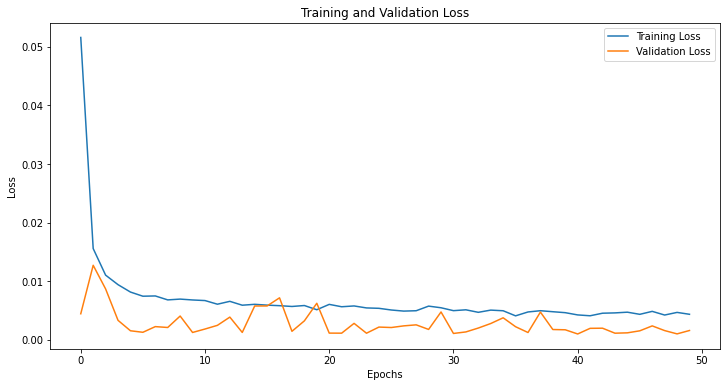

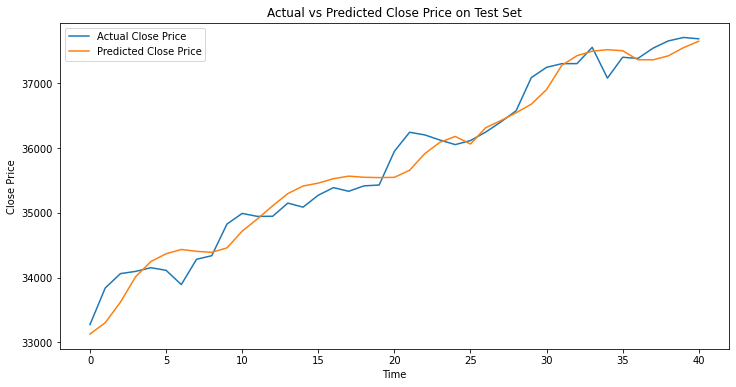

In [8]:

# Load and select the best features based on correlation with 'Close'
data = combined_data

# Selecting the best features based on correlation
selected_features = [
    'Close', 'Low', 'High', 'Open', 'sentiment_ewma_30', 
    'sentiment_ewma_14', 'sentiment_ewma_7', 'sentiment_volatility_ratio'
]
data = data[selected_features]

# Split data into training and testing sets
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

# Prepare the data for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 1:])  # Exclude 'Close' from X
        Y.append(dataset[i + look_back, 0])       # Use 'Close' as Y
    return np.array(X), np.array(Y)

look_back = 60  # Using 60 previous timesteps to predict the next timestep
X_train, y_train = create_dataset(train_scaled, look_back)
X_test, y_test = create_dataset(test_scaled, look_back)

# Reshape input to be [samples, time steps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Build LSTM model with specified hyperparameters
model = Sequential()
model.add(LSTM(128, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))  # Dropout rate set to 0.3
model.add(Dense(1))

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

# Model checkpointing and early stopping callbacks
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train the model with early stopping and model checkpointing
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=16,  # Batch size set to 16
    validation_data=(X_test, y_test), 
    callbacks=[checkpoint, early_stopping], 
    verbose=1
)

# Load the best model
model.load_weights('best_model.h5')

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions and actual values to compute metrics
train_predict = scaler.inverse_transform(np.concatenate((train_predict, np.zeros((train_predict.shape[0], data.shape[1] - 1))), axis=1))[:, 0]
y_train = scaler.inverse_transform(np.concatenate((y_train.reshape(-1, 1), np.zeros((y_train.shape[0], data.shape[1] - 1))), axis=1))[:, 0]

test_predict = scaler.inverse_transform(np.concatenate((test_predict, np.zeros((test_predict.shape[0], data.shape[1] - 1))), axis=1))[:, 0]
y_test = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], data.shape[1] - 1))), axis=1))[:, 0]

# --- Evaluation Metrics ---

# 1. RMSE
train_rmse = sqrt(mean_squared_error(y_train, train_predict))
test_rmse = sqrt(mean_squared_error(y_test, test_predict))
print(f'Train RMSE: {train_rmse:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')

# 2. MAE
train_mae = mean_absolute_error(y_train, train_predict)
test_mae = mean_absolute_error(y_test, test_predict)
print(f'Train MAE: {train_mae:.2f}')
print(f'Test MAE: {test_mae:.2f}')

# 3. R-squared
train_r2 = r2_score(y_train, train_predict)
test_r2 = r2_score(y_test, test_predict)
print(f'Train R²: {train_r2:.2f}')
print(f'Test R²: {test_r2:.2f}')

# --- Visualization ---

# 1. Loss Plot
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# 2. Predicted vs Actual Plot on Test Set
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Close Price')
plt.plot(test_predict, label='Predicted Close Price')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.title('Actual vs Predicted Close Price on Test Set')
plt.legend()
plt.show()


## 7. Results Comparison



In [9]:
import pandas as pd

# Data for comparison
data = {
    "Metric": ["Train RMSE", "Test RMSE", "Train MAE", "Test MAE", "Train R²", "Test R²"],
    "Without Sentiment Features": [614.20, 337.48, 462.72, 247.70, 0.81, 0.93],
    "With Sentiment Features": [454.12, 253.78, 352.41, 198.47, 0.90, 0.96]
}

# Create a DataFrame
comparison_table = pd.DataFrame(data)

# Display the table in Jupyter Notebook
from IPython.display import display
display(comparison_table)


,Metric,Without Sentiment Features,With Sentiment Features
0,Train RMSE,614.20,454.12
1,Test RMSE,337.48,253.78
2,Train MAE,462.72,352.41
3,Test MAE,247.70,198.47
4,Train R²,0.81,0.90
5,Test R²,0.93,0.96


## 8. Hyperparameter Tuning (Grid Search)



In [7]:

# Load and prepare data
data = combined_data
selected_features = [
   'Close', 'Low', 'High', 'Open', 'sentiment_ewma_30', 
    'sentiment_ewma_14', 'sentiment_ewma_7', 'sentiment_volatility_ratio'
]
data = data[selected_features]

# Split data
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

# Set fixed look_back value
look_back = 60

# Function to create dataset based on look_back
def create_dataset(dataset, look_back):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 1:])  # Exclude 'Close' from X
        Y.append(dataset[i + look_back, 0])       # Use 'Close' as Y
    return np.array(X), np.array(Y)

# Create training and test datasets
X_train, y_train = create_dataset(train_scaled, look_back)
X_test, y_test = create_dataset(test_scaled, look_back)

# Reshape input to be [samples, time steps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Define the grid of hyperparameters to search over
units_list = [32, 64, 128]
dropout_list = [0.1, 0.2, 0.3]
num_layers_list = [1, 2]
batch_size_list = [16, 32]

# Initialize variables to track the best configuration and performance
best_rmse = float('inf')
best_config = {}

# Loop over each combination of hyperparameters
for units in units_list:
    for dropout in dropout_list:
        for num_layers in num_layers_list:
            for batch_size in batch_size_list:
                # Build model based on current hyperparameters
                model = Sequential()
                for layer in range(num_layers):
                    # Specify input shape only for the first layer
                    if layer == 0:
                        model.add(LSTM(units=units, return_sequences=(layer < num_layers - 1), input_shape=(look_back, X_train.shape[2])))
                    else:
                        model.add(LSTM(units=units, return_sequences=(layer < num_layers - 1)))
                    model.add(Dropout(dropout))
                model.add(Dense(1))

                # Compile model
                model.compile(optimizer='adam', loss='mean_squared_error')

                # Train the model
                history = model.fit(X_train, y_train, epochs=10, batch_size=batch_size, validation_data=(X_test, y_test), verbose=0)

                # Make predictions on the validation set
                test_predict = model.predict(X_test)

                # Inverse transform predictions and actual values to compute RMSE
                test_predict = scaler.inverse_transform(np.concatenate((test_predict, np.zeros((test_predict.shape[0], data.shape[1] - 1))), axis=1))[:, 0]
                y_test_inv = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], data.shape[1] - 1))), axis=1))[:, 0]

                # Calculate RMSE for this configuration
                rmse = sqrt(mean_squared_error(y_test_inv, test_predict))
                print(f"RMSE: {rmse:.2f} | Units: {units}, Dropout: {dropout}, Layers: {num_layers}, Batch Size: {batch_size}")

                # Update best configuration if current RMSE is lower
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_config = {
                        'units': units,
                        'dropout': dropout,
                        'num_layers': num_layers,
                        'batch_size': batch_size
                    }

# Print the best configuration and RMSE
print("\nBest Configuration:")
print(f"RMSE: {best_rmse:.2f}")
print(f"Units: {best_config['units']}, Dropout: {best_config['dropout']}, Layers: {best_config['num_layers']}, Batch Size: {best_config['batch_size']}")


2/2 [==============================] - 0s 3ms/step
RMSE: 408.68 | Units: 32, Dropout: 0.1, Layers: 1, Batch Size: 16
2/2 [==============================] - 0s 4ms/step
RMSE: 1010.97 | Units: 32, Dropout: 0.1, Layers: 1, Batch Size: 32
2/2 [==============================] - 1s 7ms/step
RMSE: 526.15 | Units: 32, Dropout: 0.1, Layers: 2, Batch Size: 16
2/2 [==============================] - 1s 6ms/step
RMSE: 977.35 | Units: 32, Dropout: 0.1, Layers: 2, Batch Size: 32
2/2 [==============================] - 0s 5ms/step
RMSE: 1052.82 | Units: 32, Dropout: 0.2, Layers: 1, Batch Size: 16
2/2 [==============================] - 1s 4ms/step
RMSE: 602.49 | Units: 32, Dropout: 0.2, Layers: 1, Batch Size: 32
2/2 [==============================] - 1s 6ms/step
RMSE: 384.52 | Units: 32, Dropout: 0.2, Layers: 2, Batch Size: 16
2/2 [==============================] - 1s 6ms/step
RMSE: 2161.71 | Units: 32, Dropout: 0.2, Layers: 2, Batch Size: 32
2/2 [==============================] - 0s 4ms/step
RMSE: 942.